<a href="https://colab.research.google.com/github/dalmasm/AI/blob/Data-Science/AI_Engineer_2025_Transformers_Agents_LangGraph_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Engineer 2025 - LangGraph Basics

## Objetivo
Mostrar como setear un grafo de ejecucion basico para el framework de agentes AI LangGraph

### Detalles
- Esta serie de notebooks adapta los tutoriales oficiales de LangGraph actualizando las dependencias a las actuales cuando es necesario y agregando notas para haccerlo mas facil de entender. Este primer notebook arma un grafo minimo viable que replica el paradigma prompt modelo response.

### Referencia
Ver clase 52

### Consultas
albertcapacitaciondigital@gmail.com
    

In [1]:
pip install -U langgraph langsmith

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.5/378.5 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.7/216.7 kB 20.8 MB/s eta 0:00:00
  Attempting uninstall: langsmith
    Found existing installation: langsmith 0.4.16
    Uninstalling langsmith-0.4.16:
      Successfully uninstalled langsmith-0.4.16


2. Crear un StateGraph¶

 Un StateGraph define la estructura de este chatbot simple como una "state machine", o una serie de nodos encadenados, cada uno con su funcion dentro del grafo.

 En este ejemplo simple un nodo sera justamente el LLM, la unica funcion de esta "app demo". Los nodos se conectaran con "edges" que se usan para manejar el flujo de ejecucion entre nodos, en este caso solo habra START y END


In [7]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages

#State es un objeto de Python de tipo de dato TypedDict
#Como Python tiene tipos dinamicos (se puede usar cualquier ipo de dato)
#TypedDict especifica que solo se podran usar elementos de UN tipo de dato
#Annotated especifica el tipo (lista) y agrega una funcion que controla como
#se actualiza la coleccion (se agregan al final)
#En palabras simples estamos definiendo un tipo de dato nuevo para guardar
#los mensajes que surgen durante la ejecucion de la aplicacion
#Cada nodo recibira el State completo cada vez, y lo actualizara al finalizar
#su ejecucion, y asi por cada nodo
#Si bien ESTE notebook es un ejemplo simple SIN necesidad de almacenar el
#State del grafo, otros lo necesitaran
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

#Crear un grafo usando como State la clase creada arriba
graph_builder = StateGraph(State)

In [3]:
#LangGraph permite la ejecucion de grafos, LangChain la interaccion
#Standarizada de modelos AI
!pip install -U "langchain[google-genai]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.0/444.0 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.1 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.74
    Uninstalling langchain-core-0.3.74:
      Successfully uninstalled langchain-core-0.3.74
  Attempting uninstall: google-ai-generativelanguage
    Found existing installation: google-ai-generativelanguage 0.6.15
    Uninstalling google-ai-generativelanguage-0.6.15:
      Successfully uninstalled google-ai-generativelanguage-0.6.15
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-generativeai 0.8.5 requires google-ai-generativelanguage==0.6.15, but you have google-ai-generativelanguage 0.6.18 which is incompatible.


3. Agregamos un nodo

En este caso es el modelo. Cada nodo cumple una funcion especifica y solo una, por eso se implementan con funciones de Python

In [5]:
import os
from langchain.chat_models import init_chat_model

# Importa el gestor de secretos de Colab
from google.colab import userdata

# Accede a la clave de API usando el nombre que le diste
os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')


llm = init_chat_model("google_genai:gemini-2.0-flash")



In [8]:
#La funcion recibira el State e invocara al modelo
#devolvera obviamente el response del modelo,agregandolo al State
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


#Agregar un nodo al grafo, darle un nombre
#y especificar la funcion de Python que se ejecuta cuando se activa
graph_builder.add_node("chatbot", chatbot)

4. Especificar un punto de entrada del grafo. Notar que se especifica que nodo es el primero a ejecutar

In [9]:
graph_builder.add_edge(START, "chatbot")


5. Compilar el grafo

Para ejecutar el grafo, antes hay que compilaro, de la siguiente manera

In [10]:
graph = graph_builder.compile()

6. Visualizar el grafo

No es necesario para la ejecucion, la celda usa una funcion externa para dibujar el grafo pero se ejecutara correctamente aun sin esto

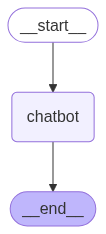

In [11]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

7. Ejecutar el grafo y usar el chatbot

In [13]:
#Esta funcion es llamada en cada interaccion con el modelo
#La funcion recibe el prompt del usuario y lo envia al grafo
#definido mas arriba, notar el formato del prompt
#Cada llamada al grafo genera un evento,que es procesado abajo
#En este caso el evento es el response del modelo que se imprime
#el -1 corresponde al ultimo mensajede toda la coleccion
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

#Loop infinito hasta que el usuario tipea quit,exit o q
while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q","bye"]:
            print("Goodbye!")
            break
        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

User: bye
Goodbye!
